In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customer_360 = pd.read_csv(
    "../data/processed/customer_360.csv",
    parse_dates=[
        "first_purchase_date",
        "last_purchase_date"
    ]
)

customer_360.shape

(96096, 47)

In [2]:
customer_360.info()

<class 'pandas.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_unique_id      96096 non-null  str           
 1   total_orders            96096 non-null  int64         
 2   total_items             96096 non-null  float64       
 3   total_spent             96096 non-null  float64       
 4   total_freight           96096 non-null  float64       
 5   unique_products         96096 non-null  float64       
 6   unique_sellers          96096 non-null  float64       
 7   avg_order_value         96096 non-null  float64       
 8   last_purchase_date      96096 non-null  datetime64[us]
 9   recency_days            96096 non-null  int64         
 10  first_purchase_date     96096 non-null  datetime64[us]
 11  customer_lifetime_days  96096 non-null  int64         
 12  active_months           96096 non-null  float64       
 1

In [3]:
customer_360.describe()

,total_orders,total_items,total_spent,total_freight,unique_products,unique_sellers,avg_order_value,last_purchase_date,recency_days,first_purchase_date,...,seller_diversity,spend_per_order,R_score,F_score,M_score,RFM_score,spend_score,frequency_score,customer_value_score,cluster
count,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096,96096.000000,96096,...,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000
mean,1.034809,1.172265,164.872141,23.433957,1.065861,1.040730,159.810187,2018-01-02 12:40:19.655865,287.735691,2017-12-30 19:19:10.429206,...,1.005691,159.810187,3.004027,2.999979,2.999729,9.003736,0.012066,0.002176,0.009099,0.043883
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2016-09-04 21:15:19,0.000000,2016-09-04 21:15:19,...,0.000000,0.000000,1.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,62.390000,13.920000,1.000000,1.000000,61.690000,2017-09-15 09:04:17.250000,163.000000,2017-09-11 19:52:06,...,1.000000,61.690000,2.000000,2.000000,2.000000,7.000000,0.004566,0.000000,0.003202,0.000000
50%,1.000000,1.000000,107.270000,17.530000,1.000000,1.000000,105.180000,2018-01-21 19:39:16,268.000000,2018-01-18 13:33:08,...,1.000000,105.180000,3.000000,3.000000,3.000000,9.000000,0.007851,0.000000,0.005535,0.000000
75%,1.000000,1.000000,182.237500,25.420000,1.000000,1.000000,176.230000,2018-05-06 20:14:49.750000,397.000000,2018-05-04 10:38:45,...,1.000000,176.230000,4.000000,4.000000,4.000000,11.000000,0.013337,0.000000,0.009647,0.000000
max,17.000000,24.000000,13664.080000,1794.960000,16.000000,16.000000,13664.080000,2018-10-17 17:30:18,772.000000,2018-10-17 17:30:18,...,5.000000,13664.080000,5.000000,5.000000,5.000000,15.000000,1.000000,1.000000,0.700000,2.000000
std,0.214384,0.627071,227.938658,22.883215,0.339595,0.265045,220.564409,NaN,153.414676,NaN,...,0.146447,220.564409,1.415035,1.414228,1.414265,2.504101,0.016682,0.013399,0.012806,0.257060


In [4]:
customer_360.isnull().sum().sort_values(ascending=False).head(10)

avg_delivery_days     2740
avg_delivery_delay    2740
max_delivery_days     2740
avg_review_score       716
max_installments         3
avg_payment_value        1
total_orders             0
unique_sellers           0
avg_order_value          0
recency_days             0
dtype: int64

In [5]:
customer_360["total_orders"].describe()

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: total_orders, dtype: float64

In [6]:
customer_360["total_orders"].value_counts().sort_index()

total_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

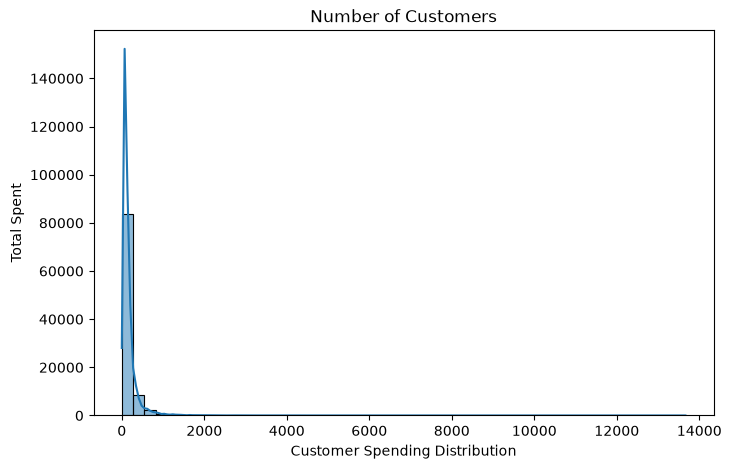

In [7]:
# Spending Distribution

plt.figure(figsize = (8,5))

sns.histplot(
    customer_360["total_spent"],
    bins = 50,
    kde = True
)

plt.xlabel("Customer Spending Distribution")
plt.ylabel("Total Spent")
plt.title("Number of Customers")
plt.show()

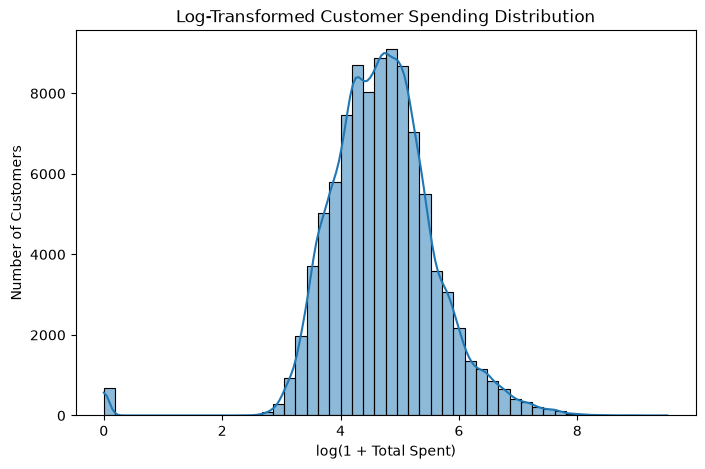

In [8]:
plt.figure(figsize = (8,5))

sns.histplot(
    np.log1p(customer_360["total_spent"]),
    bins = 50,
    kde = True
)
plt.title("Log-Transformed Customer Spending Distribution")
plt.xlabel("log(1 + Total Spent)")
plt.ylabel("Number of Customers")
plt.show()

In [9]:
#Business insight
#Log transformation reduces the effect of extreme spending values and provides a clearer view of the typical customer spending pattern.
#The distribution indicates that most customers fall within a relatively concentrated spending range, while a smaller group consists of high-value customers.


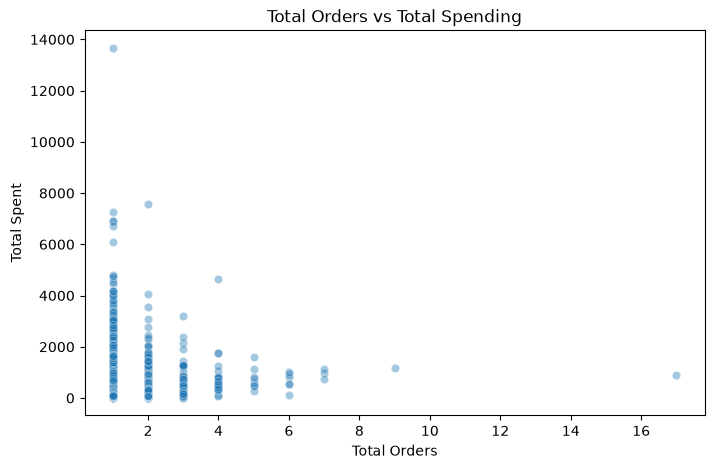

In [10]:
# Orders vs Spending

plt.figure(figsize = (8,5))

sns.scatterplot(
    data = customer_360,
    x = "total_orders",
    y = "total_spent",
    alpha = 0.4
)
plt.title("Total Orders vs Total Spending")
plt.xlabel("Total Orders")
plt.ylabel("Total Spent")
plt.show()

In [11]:
# Business Insight
# Customers with multiple orders generally generate higher total spending, indicating that repeat purchasing is an important contributor to customer value.
#  However, spending varies considerably among customers with the same number of orders,
#   showing that order frequency alone is not sufficient to 
#   identify high-value customers.


In [12]:
customer_360[
    ["total_orders", "total_spent"]
].corr()

,total_orders,total_spent
total_orders,1.000000,0.122369
total_spent,0.122369,1.000000


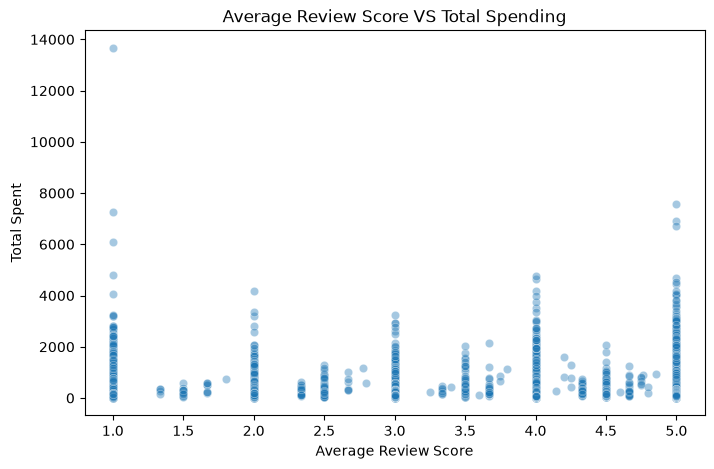

In [13]:
# Customer Reviews & Spending

plt.figure(figsize = (8,5))

sns.scatterplot(
    data = customer_360,
    x = "avg_review_score",
    y = "total_spent",
    alpha = 0.4
)

plt.title("Average Review Score VS Total Spending")
plt.xlabel("Average Review Score")
plt.ylabel("Total Spent")
plt.show()

In [ ]:
# Business Insight
Customer review scores do not show a clear relationship with total spending. 
High-spending customers are present across different 
review-score levels, suggesting that spending behavior 
is not strongly determined by review satisfaction alone.




In [14]:
customer_360[
    ["avg_review_score", "total_spent"]
].corr()

,avg_review_score,total_spent
avg_review_score,1.000000,-0.035239
total_spent,-0.035239,1.000000


In [15]:
# Business Insight
#Average review score and total spending show an extremely weak negative correlation (-0.035), indicating that customer satisfaction, as measured by review scores, does not have a meaningful linear relationship with spending in this dataset. Therefore, review score alone should not be used to identify high-value customers.

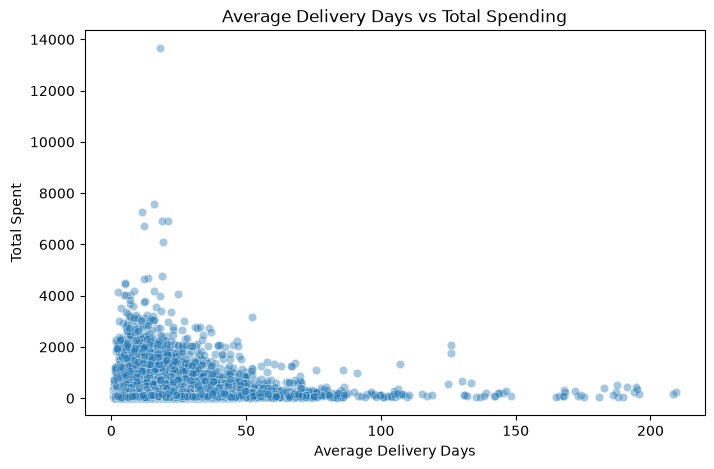

In [16]:
#Delivery Performance vs Customer Spending

plt.figure(figsize = (8,5))

sns.scatterplot(
    data = customer_360,
    x = "avg_delivery_days",
    y = "total_spent",
    alpha = 0.4
)

plt.title("Average Delivery Days vs Total Spending")
plt.xlabel("Average Delivery Days")
plt.ylabel("Total Spent")
plt.show()

In [17]:
customer_360[
    ["avg_delivery_days", "total_spent"]
].corr()

,avg_delivery_days,total_spent
avg_delivery_days,1.00000,0.06864
total_spent,0.06864,1.00000


In [ ]:
# Business Insight — preliminary

#Customers with very long delivery times generally show lower spending levels,
#  while higher-spending customers are more concentrated among customers with shorter 
# delivery times. This suggests that delivery performance
#  may be relevant to customer value, although the 
# relationship should be quantified using correlation.

In [ ]:
# Final Business Insight
# Average delivery days and total spending have a very weak
#  positive correlation (0.06864), indicating that delivery time has little linear relationship with customer spending in this dataset. Therefore, delivery duration alone is not a strong predictor of customer value.



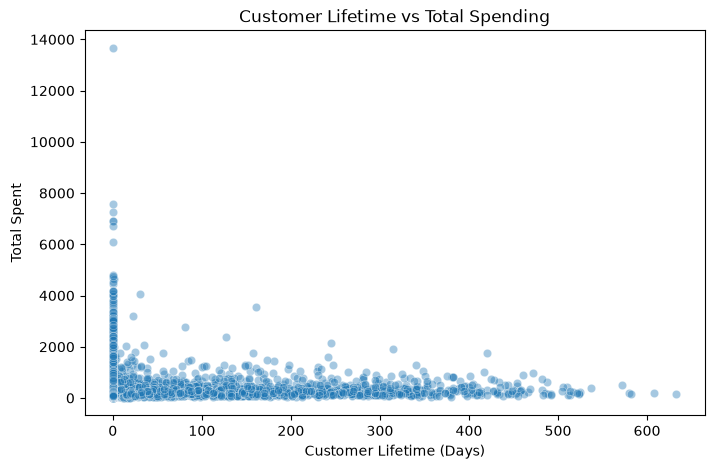

In [18]:
# customer lifetime vs total spending.

plt.figure(figsize = (8,5))

sns.scatterplot(
    data = customer_360,
    x = "customer_lifetime_days",
    y = "total_spent",
    alpha = 0.4
)

plt.title("Customer Lifetime vs Total Spending")
plt.xlabel("Customer Lifetime (Days)")
plt.ylabel("Total Spent")
plt.show()


In [19]:
customer_360[
    ["customer_lifetime_days", "total_spent"]
].corr()

,customer_lifetime_days,total_spent
customer_lifetime_days,1.000000,0.073428
total_spent,0.073428,1.000000


In [ ]:
# Customer lifetime and total spending have a very weak
#  positive correlation (0.0734), indicating that a longer 
# customer relationship does not necessarily result in 
# substantially higher spending. Therefore, customer 
# lifetime alone is not sufficient for identifying high-value 
# customers.


In [24]:
(order_summary).dtypes

total_orders         int64
customers            int64
avg_spending       float64
avg_order_value    float64
dtype: object

In [26]:
(order_summary).dtypes

total_orders         int64
customers            int64
avg_spending       float64
avg_order_value    float64
dtype: object

In [27]:
order_summary = customer_360.groupby("total_orders").agg(
    customers=("customer_unique_id", "count"),
    avg_spending=("total_spent", "mean"),
    avg_order_value=("avg_order_value", "mean")
).reset_index()

order_summary

,total_orders,customers,avg_spending,avg_order_value
0,1,93099,160.275736,160.275736
1,2,2745,290.098095,145.049047
2,3,203,431.186207,143.728736
3,4,30,773.798667,193.449667
4,5,8,759.656250,151.931250
5,6,6,664.323333,110.720556
6,7,3,946.853333,135.264762
7,9,1,1172.670000,130.296667
8,17,1,902.040000,53.061176


In [28]:
order_summary.dtypes

total_orders         int64
customers            int64
avg_spending       float64
avg_order_value    float64
dtype: object

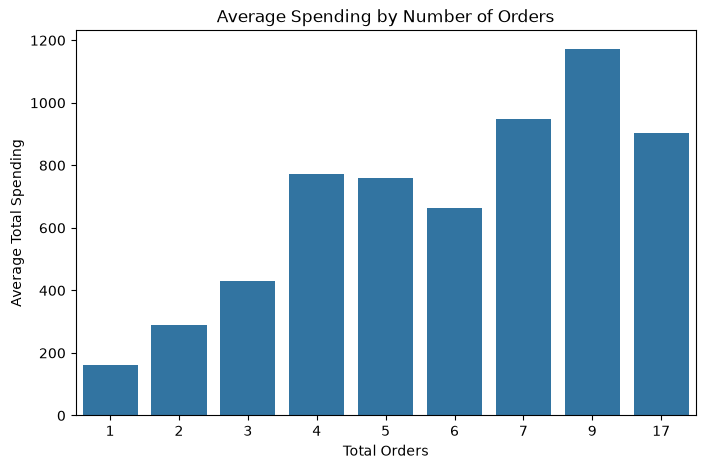

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=order_summary,
    x="total_orders",
    y="avg_spending"
)

plt.title("Average Spending by Number of Orders")
plt.xlabel("Total Orders")
plt.ylabel("Average Total Spending")
plt.show()

In [30]:
type(order_summary)

pandas.DataFrame

In [ ]:
#Average customer spending generally increases with 
# the number of orders. This indicates that 
# repeat purchasing is strongly associated with 
# higher customer value. However, the relationship
#  is not perfectly linear, and groups with very 
# high order counts should be interpreted carefully 
# because they contain fewer customers.

In [31]:
# Review Score Analysis.

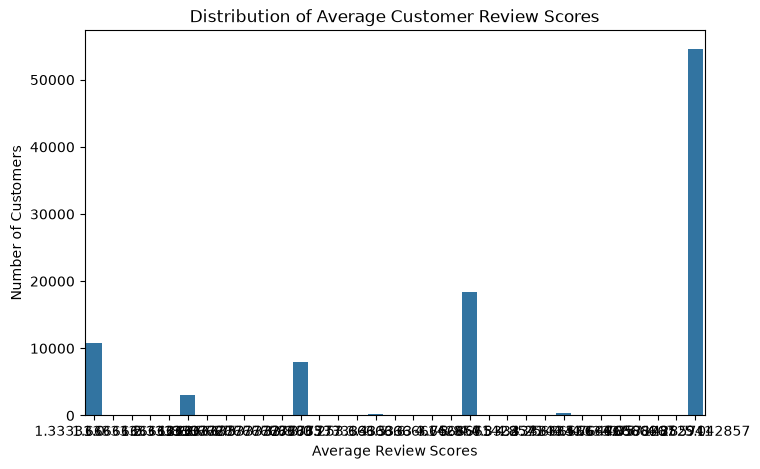

In [32]:
plt.figure(figsize = (8,5))

sns.countplot(
    data = customer_360,
    x = "avg_review_score",
)

plt.title("Distribution of Average Customer Review Scores")
plt.xlabel("Average Review Scores")
plt.ylabel("Number of Customers")
plt.show()

In [33]:
review_percentage = (
    customer_360["avg_review_score"]
    .value_counts(normalize = True)
    .sort_index()
    * 100
)

review_percentage

avg_review_score
1.000000    11.318935
1.333333     0.004194
1.500000     0.013630
1.666667     0.007339
1.800000     0.001048
2.000000     3.171524
2.333333     0.020969
2.500000     0.095408
2.666667     0.006291
2.777778     0.001048
2.800000     0.001048
3.000000     8.297337
3.250000     0.001048
3.333333     0.007339
3.400000     0.001048
3.500000     0.159363
3.600000     0.001048
3.666667     0.035647
3.750000     0.002097
3.800000     0.001048
4.000000    19.205284
4.142857     0.001048
4.200000     0.002097
4.250000     0.003145
4.333333     0.034598
4.500000     0.313483
4.600000     0.001048
4.666667     0.033550
4.750000     0.005242
4.764706     0.001048
4.800000     0.002097
4.857143     0.001048
5.000000    57.248899
Name: proportion, dtype: float64

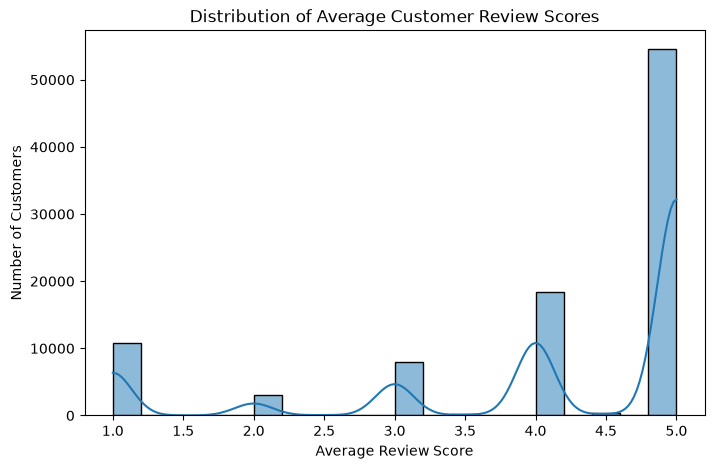

In [35]:
plt.figure(figsize = (8,5))

sns.histplot(
    customer_360["avg_review_score"].dropna(),
    bins = 20,
    kde = True
)

plt.title("Distribution of Average Customer Review Scores")
plt.xlabel("Average Review Score")
plt.ylabel("Number of Customers")
plt.show()

In [36]:
# Review Score vs Order Frequency

review_order_summary = customer_360.groupby("total_orders").agg(
    avg_review = ("avg_review_score", "mean"),
    customers = ("customer_unique_id", "count")
).reset_index()


In [37]:
review_order_summary

,total_orders,avg_review,customers
0,1,4.083979,93099
1,2,4.102887,2745
2,3,4.213054,203
3,4,4.476667,30
4,5,4.417857,8
5,6,4.392857,6
6,7,5.000000,3
7,9,2.777778,1
8,17,4.764706,1


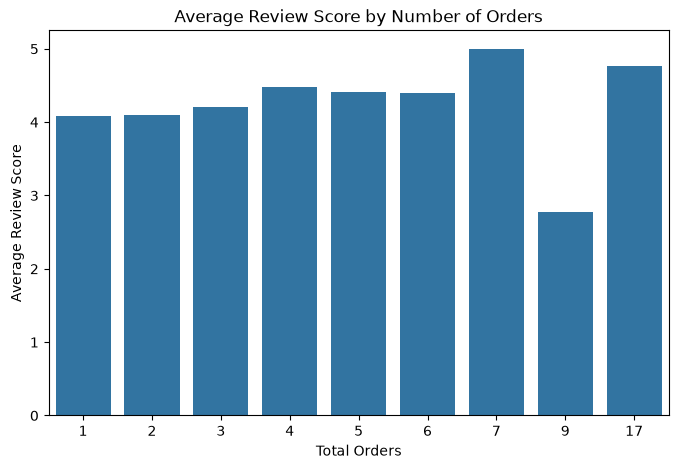

In [38]:
plt.figure(figsize = (8,5))

sns.barplot(
    data = review_order_summary,
    x = "total_orders",
    y = "avg_review",
)

plt.title("Average Review Score by Number of Orders")
plt.xlabel("Total Orders")
plt.ylabel("Average Review Score")
plt.show()

In [39]:
review_order_summary[
    ["total_orders", "customers", "avg_review"]
]

,total_orders,customers,avg_review
0,1,93099,4.083979
1,2,2745,4.102887
2,3,203,4.213054
3,4,30,4.476667
4,5,8,4.417857
5,6,6,4.392857
6,7,3,5.000000
7,9,1,2.777778
8,17,1,4.764706


In [ ]:
#Most customers are one-time purchasers, while the
#  number of customers decreases sharply as order 
# frequency increases. Average review scores remain 
# around 4 or above for the major customer groups, 
# indicating generally positive satisfaction. 
# However, review scores for very high-order groups 
# are unreliable because of their extremely small
#  sample sizes.

In [40]:
# Delivery Performance

delivery_summary = customer_360.agg(
    avg_delivery_days = ("avg_delivery_days", "mean"),
    avg_delivery_delay = ("avg_delivery_delay","mean"),
    late_orders = ("late_orders","sum"),
    on_time_orders = ("on_time_orders","sum")
)

In [41]:
delivery_summary

,avg_delivery_days,avg_delivery_delay,late_orders,on_time_orders
avg_delivery_days,12.567974,NaN,NaN,NaN
avg_delivery_delay,NaN,-11.151587,NaN,NaN
late_orders,NaN,NaN,7827.0,NaN
on_time_orders,NaN,NaN,NaN,0.0


In [42]:
customer_360["on_time_orders"].value_counts(dropna=False)

on_time_orders
0    96096
Name: count, dtype: int64

In [43]:
customer_360["on_time_orders"].dtype

dtype('int64')

In [44]:
customer_360[["late_orders", "on_time_orders"]].head(10)

,late_orders,on_time_orders
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,1,0


In [45]:
customer_360["late_orders"].describe()

count    96096.000000
mean         0.081450
std          0.275686
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: late_orders, dtype: float64

In [46]:
#Late deliveries are relatively uncommon at the 
# customer level. The median number of late orders 
# is 0, and 75% of customers have no late orders.
#  Only a smaller group of customers experienced one 
# or more late deliveries, with a maximum of three 
# late orders per customer. This suggests that late
#  delivery is concentrated among a relatively 
# small portion of customers.


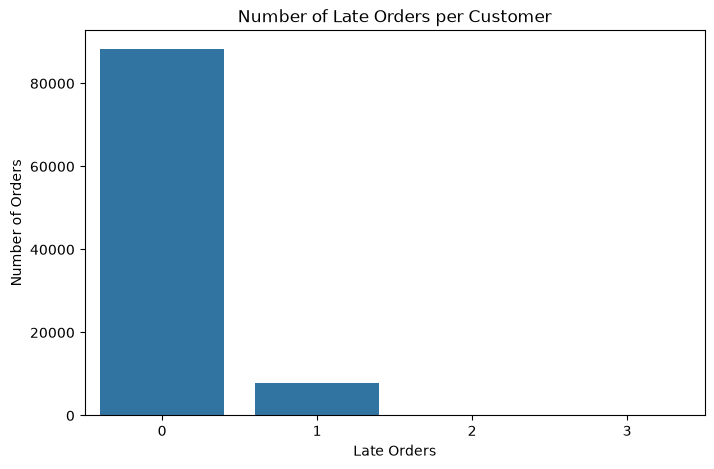

In [ ]:
plt.figure(figsize = (8,5))

sns.countplot(
    data = customer_360,
    x = "late_orders"
)

plt.title("Number of Late Orders per Customer")
plt.xlabel("Late Orders")
plt.ylabel("Number of Late Orders")
plt.show()

In [ ]:
#Late deliveries are concentrated among a relatively 
# small group of customers. Most customers experienced
#  no late orders, while customers with two or three
#  late orders are very rare. This indicates that 
# repeated delivery problems affect a small portion 
# of the customer base and may be useful for
#  identifying customers at risk of dissatisfaction
#  or churn.

In [50]:
#Customer Segment vs Spending

segment_summary = customer_360.groupby("customer_segment").agg(
    customers = ("customer_unique_id", "count"),
    avg_spending = ("total_spent", "mean"),
    total_revenue = ("total_spent","sum"),
    avg_orders = ("total_orders", "mean")
).reset_index()



In [51]:
segment_summary

,customer_segment,customers,avg_spending,total_revenue,avg_orders
0,High Value,8309,335.276849,2785815.34,1.210013
1,Low Value,15926,63.506989,1011412.30,1.000000
2,Loyal,32417,214.944847,6967867.10,1.043619
3,Potential,39444,128.751103,5078458.50,1.004716


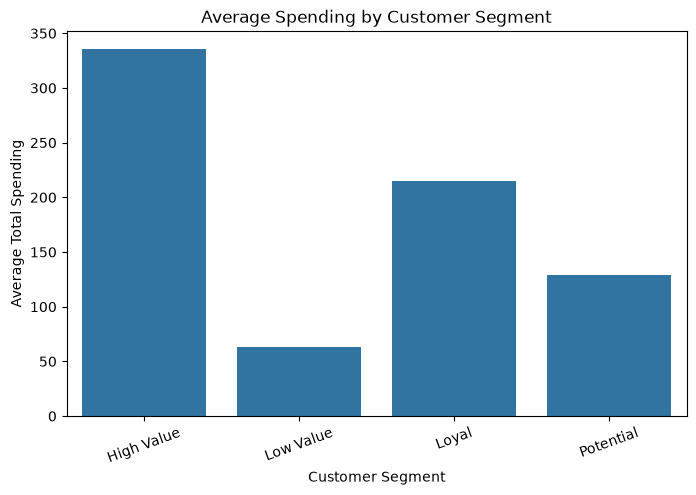

In [52]:
plt.figure(figsize = (8,5))

sns.barplot(
    data = segment_summary,
    x = "customer_segment",
    y = "avg_spending"
)

plt.title("Average Spending by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Total Spending")
plt.xticks(rotation = 20)
plt.show()

In [ ]:
#High Value customers have the highest average 
# spending, followed by Loyal, Potential, and Low 
# Value customers. This indicates that the customer
#  segmentation effectively differentiates customers 
# based on their purchasing value. High Value and
#  Loyal customers should therefore receive greater
#  retention and personalized engagement efforts.




In [54]:
segment_summary[
    ["customer_segment", "customers"]
]

,customer_segment,customers
0,High Value,8309
1,Low Value,15926
2,Loyal,32417
3,Potential,39444


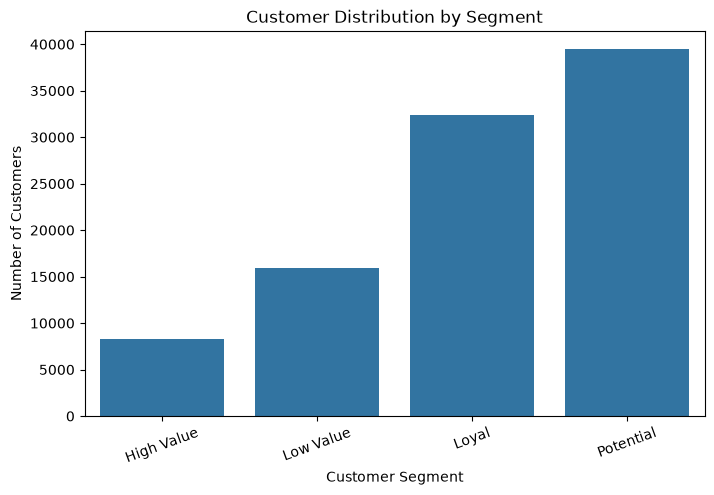

In [56]:
plt.figure(figsize = (8,5))

sns.barplot(
    data = segment_summary,
    x = "customer_segment",
    y = "customers"
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

In [ ]:
#otential customers form the largest customer segment,
#  followed by Loyal customers. High Value customers 
# represent the smallest segment but have the highest
#  average spending. This suggests that the business
#  has a large opportunity to convert Potential
#  customers into Loyal or High Value customers 
# through targeted engagement and personalized offers.

In [57]:
# Compare Segment Size + Revenue

segment_summary[
    ["customer_segment", "customers", "avg_spending", "total_revenue"]
]

,customer_segment,customers,avg_spending,total_revenue
0,High Value,8309,335.276849,2785815.34
1,Low Value,15926,63.506989,1011412.30
2,Loyal,32417,214.944847,6967867.10
3,Potential,39444,128.751103,5078458.50


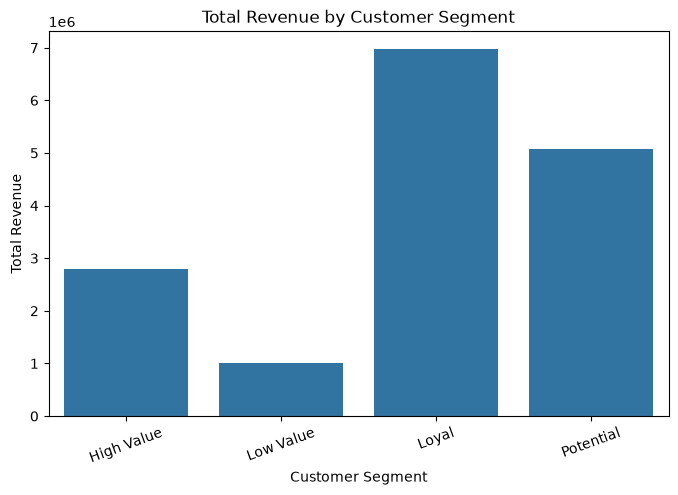

In [58]:
plt.figure(figsize = (8,5))

sns.barplot(
    data = segment_summary,
    x = "customer_segment",
    y = "total_revenue"
)

plt.title("Total Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation = 20)
plt.show()

In [59]:
# Revenue Contribution %

segment_summary["revenue_percentage"] =(
    segment_summary["total_revenue"]
    / segment_summary["total_revenue"].sum()
    * 100
)


segment_summary[
    ["customer_segment","customers", "total_revenue","revenue_percentage"]
]


,customer_segment,customers,total_revenue,revenue_percentage
0,High Value,8309,2785815.34,17.583274
1,Low Value,15926,1011412.30,6.383747
2,Loyal,32417,6967867.10,43.979195
3,Potential,39444,5078458.50,32.053785


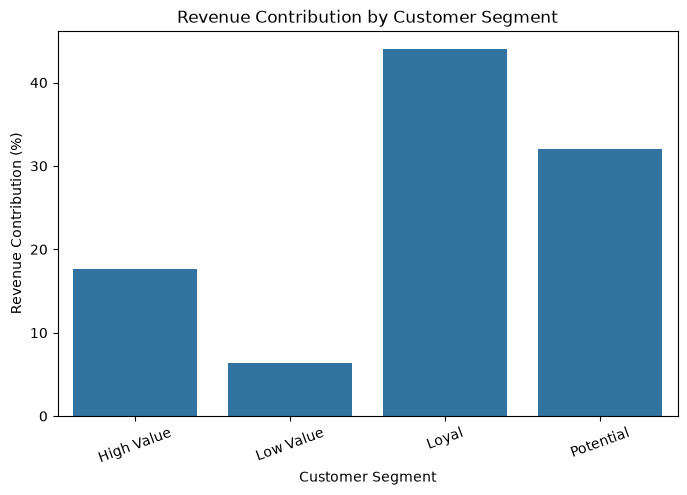

In [60]:
plt.figure(figsize = (8,5))

sns.barplot(
    data = segment_summary,
    x = "customer_segment",
    y = "revenue_percentage"
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue Contribution (%)")
plt.xticks(rotation= 20)
plt.show()

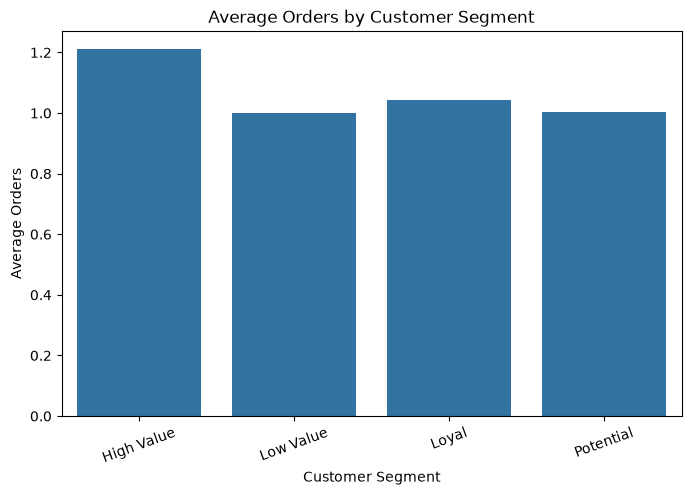

In [61]:
# Customer Segment vs Order Frequency

plt.figure(figsize = (8,5))

sns.barplot(
    data = segment_summary,
    x = "customer_segment",
    y = "avg_orders"
)

plt.title("Average Orders by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Orders")
plt.xticks(rotation=20)
plt.show()


In [62]:
segment_summary[
    ["customer_segment", "customers", "avg_orders"]
]

,customer_segment,customers,avg_orders
0,High Value,8309,1.210013
1,Low Value,15926,1.000000
2,Loyal,32417,1.043619
3,Potential,39444,1.004716


In [ ]:
# High Value customers have the highest average order
#  frequency (1.21 orders per customer),
#  while the other segments remain close to
#  one order per customer. The relatively small 
# differences indicate that segment differentiation 
# is driven by multiple customer-value characteristics 
# rather than order frequency alone.

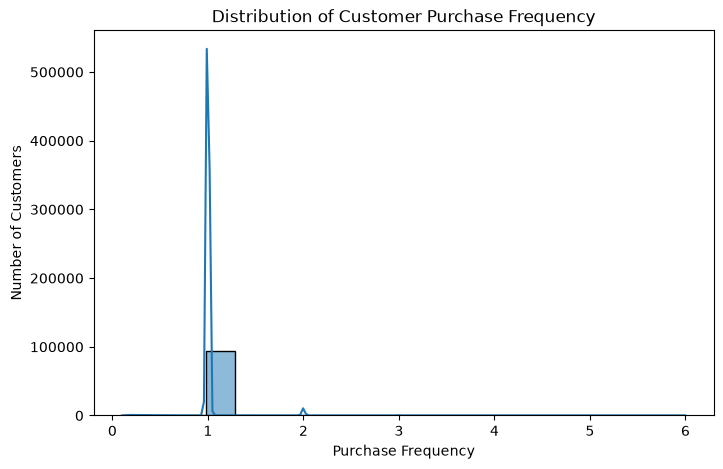

In [63]:
# Purchase Frequency Distribution

plt.figure(figsize = (8,5))

sns.histplot(
    data = customer_360,
    x = "purchase_frequency",
    bins = 20,
    kde = True
)

plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Purchase Frequency")
plt.ylabel("Number of Customers")
plt.show()

In [64]:
customer_360["purchase_frequency"].describe()

count    96096.000000
mean         1.010582
std          0.153080
min          0.098684
25%          1.000000
50%          1.000000
75%          1.000000
max          6.000000
Name: purchase_frequency, dtype: float64

In [65]:
# Customer purchase frequency is highly concentrated 
# around 1. The median and 75th percentile are both 1, 
# indicating that most customers have very limited 
# repeat-purchase activity. A small number of customers 
# have substantially higher purchase frequencies,
#  reaching a maximum of 6. This highlights repeat
# -purchase behavior as an important opportunity for 
# customer retention and growth.

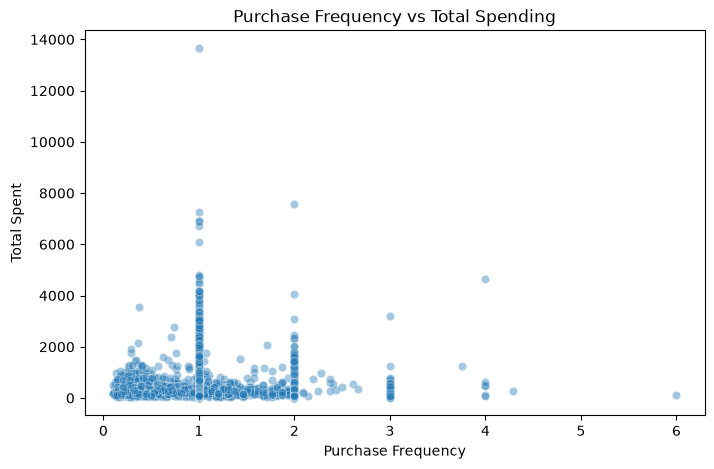

In [68]:
# Purchase Frequency vs Total Spending

plt.figure(figsize = (8,5))

sns.scatterplot(
    data = customer_360,
    x = "purchase_frequency",
    y = "total_spent",
    alpha = 0.4
)

plt.title("Purchase Frequency vs Total Spending")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spent")
plt.show()

In [69]:
customer_360[
    ["purchase_frequency", "total_spent"]
].corr()

,purchase_frequency,total_spent
purchase_frequency,1.000000,0.044749
total_spent,0.044749,1.000000


In [70]:
business_kpis = {
    "Total Customers": customer_360["customer_unique_id"].nunique(),
    "Total Revenue": customer_360["total_spent"].sum(),
    "Average Customer Spend": customer_360["total_spent"].mean(),
    "Median Customer Spend": customer_360["total_spent"].median(),
    "Average Orders per Customer": customer_360["total_orders"].mean(),
    "Repeat Customer %": (
        (customer_360["total_orders"] > 1).mean() * 100
    ),
    "Average Review Score": customer_360["avg_review_score"].mean(),
    "Customers with Late Orders %": (
        (customer_360["late_orders"] > 0).mean() * 100
    )
}

business_kpis

{'Total Customers': 96096,
 'Total Revenue': np.float64(15843553.24),
 'Average Customer Spend': np.float64(164.87214077589078),
 'Median Customer Spend': np.float64(107.27),
 'Average Orders per Customer': np.float64(1.0348089410589412),
 'Repeat Customer %': np.float64(3.1187562437562435),
 'Average Review Score': np.float64(4.084989436817573),
 'Customers with Late Orders %': np.float64(8.087745587745587)}

In [71]:
customer_360.to_csv(
    "../data/processed/customer_360.csv",
    index=False
)

In [72]:
import os

os.path.exists("../data/processed/customer_360.csv")

True